## Milestone 1 EDA

### Read Raw Data

NOTE: Before running this, ensure that the `Patio_Lawn_and_Garden` dataset has been unpacked into `data/raw`.

In [1]:
from langchain_core.documents import Document
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd
import duckdb
import time
import csv
import json
import os

## Create Samples of the Data

This is to view a small sample of the data so that we know what we are working with.

In [2]:
REVIEWS_IN  = '../data/raw/Patio_Lawn_and_Garden.jsonl'
META_IN = '../data/raw/meta_Patio_Lawn_and_Garden.jsonl'
FORCE_RUN = False # If True, recreates the CSV and Parquet files regardless of if they already exist, in case something went wrong with them

In [3]:
reviews_df = pd.read_json(REVIEWS_IN, lines = True, chunksize = 100)
metadata_df = pd.read_json(META_IN, lines = True, chunksize = 100)

In [4]:
first_reviews = next(reviews_df)
first_reviews.to_json("../data/processed/Patio_Lawn_and_Garden_sample.jsonl",orient='records', indent=4)
first_meta = next(metadata_df)
first_meta.to_json("../data/processed/meta_Patio_Lawn_and_Garden_sample.jsonl",orient='records', indent=4)

<positron-console-cell-4>:2: Pandas4Warning: The default 'epoch' date format is deprecated and will be removed in a future version, please use 'iso' date format instead.


In [5]:
first_reviews.head()

,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase
0,1,Someone’s return? Arrived broken in several pl...,Seriously. Not my best month with Amazon. Open...,[{'small_image_url': 'https://images-na.ssl-im...,B00KGVWNRG,B07CL2CD4D,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,2021-04-21 00:33:51.473,0,False
1,1,Arrived broken,The chair wouldn't fold out properly. The foot...,[],B00I4Z8GCM,B0C6HJPJXL,AGGZ357AO26RQZVRLGU4D4N52DZQ,2022-08-23 13:32:57.742,0,True
2,1,Disappointing,Bought this on a Cyber Monday deal and I'm so ...,[],B01CHG9MXA,B01CHG9MXA,AGGZ357AO26RQZVRLGU4D4N52DZQ,2016-12-13 21:46:16.000,0,True
3,3,Cute style but just ok- don't buy more than 1 ...,Bought these because of the unique look. I pur...,[],B004BK1DL0,B004BK1DL0,AGKASBHYZPGTEPO6LWZPVJWB2BVA,2022-05-21 23:03:26.096,1,True
4,5,Seriously I have tried just about everything. ...,Seriously I have tried just about everything. ...,[],B004CSWPS6,B004CSWPS6,AGCI7FAH4GL5FI65HYLKWTMFZ2CQ,2016-09-17 20:36:07.000,0,False


In [6]:
first_meta.head()

,main_category,title,average_rating,rating_number,features,description,price,images,videos,store,categories,details,parent_asin,bought_together
0,Amazon Home,AISEN Carburetor AIR Filter Tune UP KIT for C1...,3.8,8,[Fits for Echo PB-2155 Leaf Debris Blower ES-2...,[],18.26,[{'thumb': 'https://m.media-amazon.com/images/...,[],AISEN,"[Patio, Lawn & Garden, Outdoor Power Tools, Re...",{'Package Dimensions': '4.57 x 3.03 x 1.34 inc...,B074C2TTV8,NaN
1,Amazon Home,Orbit 57946 B-hyve Smart 6-Zone Indoor/Outdoor...,4.5,12815,[WELCOME TO B-HYVE: Looking to get a smart spr...,"[From the manufacturer, Orbit is North America...",99.17,[{'thumb': 'https://m.media-amazon.com/images/...,[{'title': 'Most affordable Smart Home Sprinkl...,Orbit,"[Patio, Lawn & Garden, Gardening & Lawn Care, ...","{'Product Dimensions': '3 x 9 x 8 inches', 'It...",B0BCZK8S44,NaN
2,Amazon Home,KafePross Merry Monogram M Decorative Garden F...,4.1,9,"[Mini garden flag (size: 12.5"" x 18"") are made...","[KafePross have a lot of flag design, there ar...",9.99,[{'thumb': 'https://m.media-amazon.com/images/...,[],KafePross,"[Patio, Lawn & Garden, Outdoor Décor, Flags]",{'Package Dimensions': '9.37 x 6.14 x 0.47 inc...,B08K362CRS,NaN
3,Amazon Home,Kwik Covers 8' Rectangle Plastic Table Covers ...,4.5,346,[Kwik-Covers are hygienic table covers and dis...,"[8' x 30"" Kwik-Cover is a lightweight, elastic...",35.95,[{'thumb': 'https://m.media-amazon.com/images/...,[{'title': 'Take a closer look at the table co...,Kwik Covers,"[Patio, Lawn & Garden, Patio Furniture & Acces...","{'Brand': 'Kwik Covers', 'Color': 'Orange', 'M...",B06XVX7YQT,NaN
4,Amazon Home,Agfabric Plant Cover Warm Worth Frost Blanket ...,3.1,3,[SUITABLE SIZE Perfect for Greenhouse size 90'...,[Agfabric Plant cover made with high quality s...,NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[],Agfabric,"[Patio, Lawn & Garden, Gardening & Lawn Care, ...",{'Package Dimensions': '15.98 x 12.99 x 4.02 i...,B01I9NNPYW,NaN


### Load and Clean 'Reviews' Raw JSONL file

In [7]:
REVIEW_COLS = first_reviews.columns
print(f"Review Columns: {REVIEW_COLS}")

Review Columns: Index(['rating', 'title', 'text', 'images', 'asin', 'parent_asin', 'user_id',
       'timestamp', 'helpful_vote', 'verified_purchase'],
      dtype='str')


In [8]:
REVIEWS_OUT = '../data/processed/reviews_clean.csv'

KEEP_REVIEW_COLS = ['parent_asin', 'rating', 'title', 'text', 'helpful_vote']

In [9]:
def extract_medium_image(images):                                            # 'images'=list of dicts with different URLs =>  only want one image /review
    if not isinstance(images, list):                        
        return None
    for img in images:
        if isinstance(img, dict) and img.get('attachment_type') != 'IMAGE':     # attachment_type IMAGE => not product photos => skip [
            return img.get('medium')
    return None

def extract_review_csv():
    start = time.time()                                                               # set timer 
    with open(REVIEWS_IN, 'r', encoding='utf-8') as fin, \
        open(REVIEWS_OUT, 'w', newline='', encoding='utf-8') as fout:                  # open compressed input for streaming + csv for output
        writer = None                                                                   # csv writer init 
        kept, dropped = 0, 0                                                             # counters

        for line in fin:
            record = json.loads(line)                                                      # each line=JSON object => parse into a dict
            if not record.get('verified_purchase', False):                                  # drop unverified purchases => likely to be spam or other
                dropped += 1
                continue
            if not record.get('text', '').strip():                                            # drop reviews without  text => not useful 
                dropped += 1
                continue
            row = {col: record.get(col) for col in KEEP_REVIEW_COLS}                            # pull only listed columns
            row['image_url'] = extract_medium_image(record.get('images', []))                  # replace full images list with single medium URL    
            if writer is None:                                                                # initialise csv writer on first valid row 
                writer = csv.DictWriter(fout, fieldnames=row.keys())
                writer.writeheader()
            writer.writerow(row)
            kept += 1

            if (kept + dropped) % 1_500_000 == 0:                                          # heartbeat every 1.5M lines for pulse-check :) 
                elapsed = time.time() - start
                print(f"  {kept + dropped:,} lines processed in {elapsed:.1f}s")

    elapsed = time.time() - start
    print(f"\nDone in {elapsed:.1f}s  |  Kept: {kept:,}  |  Dropped: {dropped:,}")

In [10]:
if not Path(REVIEWS_OUT).exists() or FORCE_RUN:
    extract_review_csv()

### Load and Clean 'Meta' Raw JSONL file

In [11]:
META_COLS = first_meta.columns
print(f"Meta Columns: {META_COLS}")

Meta Columns: Index(['main_category', 'title', 'average_rating', 'rating_number', 'features',
       'description', 'price', 'images', 'videos', 'store', 'categories',
       'details', 'parent_asin', 'bought_together'],
      dtype='str')


In [12]:
META_OUT = '../data/processed/meta_clean.csv'

KEEP_META_COLS = ['parent_asin', 'title', 'average_rating', 'rating_number',
                  'features', 'description', 'price', 'store', 'details']

In [13]:
def extract_medium_image_meta(images):
    if not isinstance(images, list) or not images:
        return None
    first = images[0]
    return first.get('medium') if isinstance(first, dict) else None

def extract_meta_csv():
    start = time.time()
    with open(META_IN, 'r', encoding='utf-8') as fin, \
        open(META_OUT, 'w', newline='', encoding='utf-8') as fout:
        writer = None
        kept, dropped = 0, 0

        for line in fin:
            record = json.loads(line)
            if not record.get('title', '').strip():
                dropped += 1
                continue
            row = {col: record.get(col) for col in KEEP_META_COLS}
            row['image_url'] = extract_medium_image_meta(record.get('images', []))
            if writer is None:
                writer = csv.DictWriter(fout, fieldnames=row.keys())
                writer.writeheader()
            writer.writerow(row)
            kept += 1

            if (kept + dropped) % 100_000 == 0:                                    # heartbeat every 100K lines
                elapsed = time.time() - start
                print(f"  {kept + dropped:,} lines processed in {elapsed:.1f}s")

    elapsed = time.time() - start
    print(f"\nDone in {elapsed:.1f}s  |  Kept: {kept:,}  |  Dropped: {dropped:,}")

In [14]:
if not Path(META_OUT).exists() or FORCE_RUN:
    extract_meta_csv()

In [15]:
print("Preprocessing decisions:")
print(f"Drop columns from Reviews DF:{list(set(REVIEW_COLS) - set(KEEP_REVIEW_COLS))}")
print(f"Drop columns from Meta DF:{list(set(META_COLS) - set(KEEP_META_COLS))}")

Preprocessing decisions:
Drop columns from Reviews DF:['timestamp', 'images', 'user_id', 'asin', 'verified_purchase']
Drop columns from Meta DF:['videos', 'main_category', 'bought_together', 'images', 'categories']


<b>We decided to drop the columns above as they did not provide meaningful insight or add any useful data comparisons for us to analyse compared to the chosen columns. This was also to reduce the size of the imported data as much as possible.</b>

### Convert Cleaned CSV Files to Parquet 

It's making a lot of sense to take advantage of the parquet to duckdb SQL query efficiency for this project; so that's what we'll do!

In [16]:
if not Path('../data/processed/meta_clean.parquet').exists() or FORCE_RUN: 
    meta_df = pd.read_csv(META_OUT)
    print(f"Meta shape: {meta_df.shape}")
    meta_df['price'] = pd.to_numeric(meta_df['price'], errors='coerce')     # coerce 'price' to numeric => if can't be converted => NaN
    meta_df.to_parquet('../data/processed/meta_clean.parquet', index=False)
    print(f"{META_OUT} converted to Parquet.")
else:
    print(f"Parquet file for {META_OUT} already exists.")

if not Path('../data/processed/reviews_clean.parquet').exists() or FORCE_RUN:
    reviews_df = pd.read_csv(REVIEWS_OUT)
    print(f"Reviews shape: {reviews_df.shape}")
    reviews_df.to_parquet('../data/processed/reviews_clean.parquet', index=False)
    print(f"{REVIEWS_OUT} converted to Parquet.")
else:
    print(f"Parquet file for {REVIEWS_OUT} already exists.")

    

Parquet file for ../data/processed/meta_clean.csv already exists.
Parquet file for ../data/processed/reviews_clean.csv already exists.


### Create DuckDB Tables

In [17]:
con = duckdb.connect('../data/processed/amazon_reviews.duckdb')

con.execute("""
    CREATE TABLE IF NOT EXISTS meta AS 
    SELECT * FROM read_parquet('../data/processed/meta_clean.parquet')
""")

con.execute("""
    CREATE TABLE IF NOT EXISTS reviews AS 
    SELECT * FROM read_parquet('../data/processed/reviews_clean.parquet')
""")

print("Tables created.")

Tables created.


#### Verify Connections

In [18]:
print(con.execute("SELECT COUNT(*) FROM meta").fetchone())
print(con.execute("SELECT COUNT(*) FROM reviews").fetchone())
print(con.execute("SELECT * FROM meta LIMIT 3").fetchdf())

(367832,)
(15495259,)
  parent_asin                                              title  \
0  B074C2TTV8  AISEN Carburetor AIR Filter Tune UP KIT for C1...   
1  B0BCZK8S44  Orbit 57946 B-hyve Smart 6-Zone Indoor/Outdoor...   
2  B08K362CRS  KafePross Merry Monogram M Decorative Garden F...   

   average_rating  rating_number  \
0             3.8              8   
1             4.5          12815   
2             4.1              9   

                                            features  \
0  ['Fits for Echo PB-2155 Leaf Debris Blower ES-...   
1  ['WELCOME TO B-HYVE: Looking to get a smart sp...   
2  ['Mini garden flag (size: 12.5" x 18") are mad...   

                                         description  price      store  \
0                                                 []  18.26      AISEN   
1  ['From the manufacturer', 'Orbit is North Amer...  99.17      Orbit   
2  ['KafePross have a lot of flag design, there a...   9.99  KafePross   

                                      

### Cast DuckDB Types to VARCHAR 

In [19]:
meta_result = con.sql("""
    SELECT
        parent_asin,
        CAST(title AS VARCHAR)       AS title,
        CAST(features AS VARCHAR)    AS features,
        CAST(description AS VARCHAR) AS description,
        average_rating,
        price,
        store,
        CAST(image_url AS VARCHAR)   AS image_url
    FROM meta
""")

In [20]:
reviews_result = con.sql("""
    SELECT 
        (COALESCE(CAST(title AS VARCHAR), '') || ' ' || COALESCE(CAST(text AS VARCHAR), '')) AS combined_content,
        parent_asin, 
        CAST(title AS VARCHAR) AS title, 
        rating, 
        helpful_vote, 
        CAST(image_url AS VARCHAR) AS image_url
    FROM reviews
""")

### Convert into LangChain Document Objects

In [21]:

def stream_reviews(relation):
    # Fetch in batches of 100,000 to balance speed and RAM
    record_batch_reader = relation.fetch_record_batch(rows_per_batch=100_000)
    
    for batch in record_batch_reader:
        # Convert the Arrow batch to a list of dictionaries for easy access
        for row in batch.to_pylist():
            yield Document(
                page_content=row['combined_content'],
                metadata={
                    'parent_asin': row['parent_asin'],
                    'title': row['title'],
                    'rating': row['rating'],
                    'helpful_vote': row['helpful_vote'],
                    'image_url': row['image_url']
                }
            )

# Use the generator
review_docs = stream_reviews(reviews_result)

print(f"Documents created: {reviews_result.count('*').fetchone()[0]}")

# Output the first document from the generator
first_doc = next(review_docs)
print(first_doc)


Documents created: 15495259
page_content='Arrived broken The chair wouldn't fold out properly. The foot end wouldn't fold down past 90 degrees. Of course I consulted the directions for folding and unfolding the chair and followed that exactly. I even had my engineer cousin try to figure it out, and he couldn't get it to open either. Unfortunately I didn't try out the chair until the return window closed, so I'm stuck with a poorly made, expensive piece of junk.' metadata={'parent_asin': 'B0C6HJPJXL', 'title': 'Arrived broken', 'rating': 1.0, 'helpful_vote': 0, 'image_url': None}


In [22]:
def stream_meta(relation):
    # Fetch in batches of 100,000 to balance speed and RAM
    record_batch_reader = relation.fetch_record_batch(rows_per_batch=100_000)
    
    for batch in record_batch_reader:
        # Convert the Arrow batch to a list of dictionaries for easy access
        for row in batch.to_pylist():
            yield Document(
                page_content=f"{row['title']} {row['features']} {row['description']}",
                metadata={
                    'parent_asin': row['parent_asin'],
                    'title': row['title'],
                    'average_rating': row['average_rating'],
                    'price': row['price'],
                    'store': row['store'],
                    'image_url': row['image_url'],
                }
            )

# Use the generator
meta_docs = stream_meta(meta_result)

print(f"Documents created: {meta_result.count('*').fetchone()[0]}")

# Output the first document from the generator
first_doc = next(meta_docs)
print(first_doc)



Documents created: 367832
page_content='AISEN Carburetor AIR Filter Tune UP KIT for C1U-K43 Echo PB-2155 ES-2100 12520020660 12520020661 12520020662 12520020663 12520020664 12520020665 ['Fits for Echo PB-2155 Leaf Debris Blower ES-2100 Shredder', 'Replaces for Echo 12520020660,12520020661,12520020662,12520020663,12520020664,12520020665', 'Replaces for C1U-K43,C1U-K43A,C1U-K43B'] []' metadata={'parent_asin': 'B074C2TTV8', 'title': 'AISEN Carburetor AIR Filter Tune UP KIT for C1U-K43 Echo PB-2155 ES-2100 12520020660 12520020661 12520020662 12520020663 12520020664 12520020665', 'average_rating': 3.8, 'price': 18.26, 'store': 'AISEN', 'image_url': None}


The creation of these generators is surprisingly fast, the simplest method to utilizing Langchain in this may be to just move the generator code to helper functions and call as necessary for each query. From prompting Gemini this was the suggested code continuation for setting up the BM25 method. There are a few additions necessary here (mainly tokenization) but a similar method for semantics should be possible.

```python
# 1. Create the FTS index in DuckDB
con.execute("PRAGMA create_fts_index('reviews', 'combined_content', 'parent_asin', 'title')")

# 2. Search using SQL (This is effectively BM25)
query = "comfortable running shoes"
results = con.execute(f"""
    SELECT *, fts_main_reviews.match_bm25(parent_asin, '{query}') AS score
    FROM reviews
    WHERE score IS NOT NULL
    ORDER BY score DESC
    LIMIT 10
""").df()
```

In [23]:
con = duckdb.connect('../data/processed/amazon_reviews.duckdb')
con.execute("SHOW TABLES").df()

,name
0,meta
1,meta_search
2,reviews


### Plot Rating Distribution of Reviews

In [24]:
os.makedirs('../results/plots', exist_ok=True)

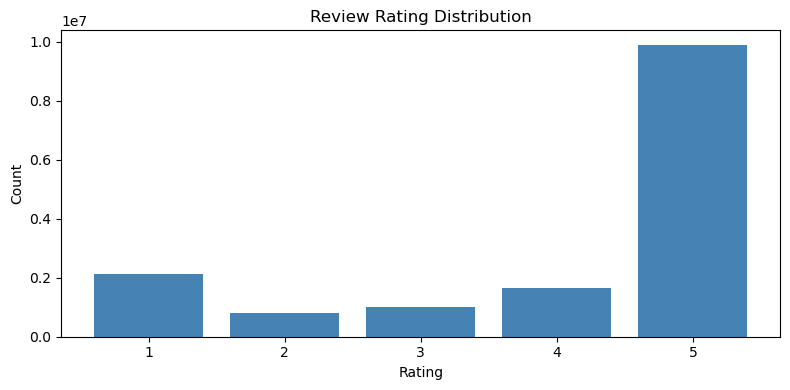

In [25]:
rating_dist = con.execute("""
    SELECT rating, COUNT(*) AS count
    FROM reviews
    GROUP BY rating
    ORDER BY rating
""").fetchdf()

plt.figure(figsize=(8, 4))
plt.bar(rating_dist['rating'], rating_dist['count'], color='steelblue')
plt.title('Review Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.xticks([1, 2, 3, 4, 5])
plt.tight_layout()
plt.savefig('../results/plots/review_rating_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

<b> The rating disttribution is heavily skewed towards 5-Star ratings </b>

### Plot Product Average Rating Distribution

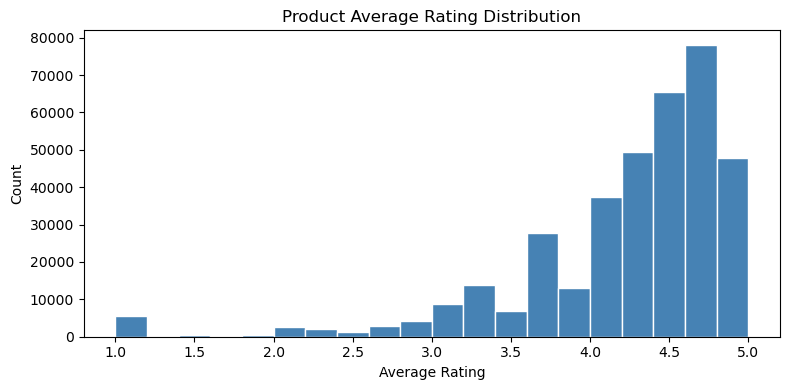

In [26]:
avg_rating_dist = con.execute("""
    SELECT average_rating
    FROM meta
    WHERE average_rating IS NOT NULL
""").fetchdf()

plt.figure(figsize=(8, 4))

plt.hist(avg_rating_dist['average_rating'], bins=20, color='steelblue', edgecolor='white')
plt.title('Product Average Rating Distribution')
plt.xlabel('Average Rating')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('../results/plots/product_average_rating_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### Plot Review Text Length Distribution  

100% ▕██████████████████████████████████████▏ (00:00:02.06 elapsed)     
 99% ▕█████████████████████████████████████▌▏ (<1 second remaining)     

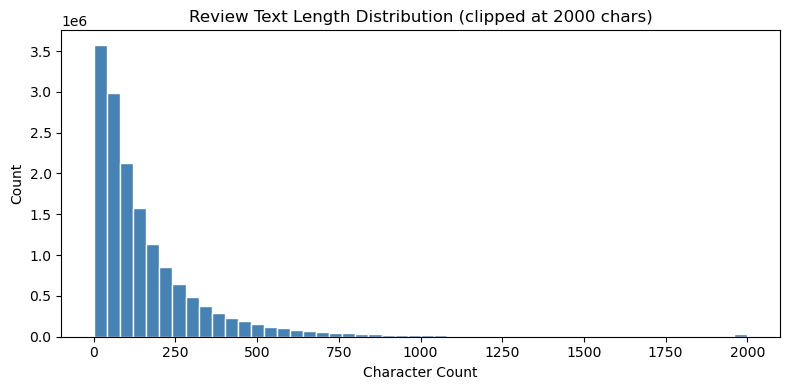

In [27]:
review_lengths = con.execute("""
    SELECT LENGTH(text) AS char_count
    FROM reviews
    WHERE text IS NOT NULL
""").fetchdf()

plt.figure(figsize=(8, 4))
plt.hist(review_lengths['char_count'].clip(upper=2000), bins=50, color='steelblue', edgecolor='white')
plt.title('Review Text Length Distribution (clipped at 2000 chars)')
plt.xlabel('Character Count')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('../results/plots/review_text_length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

<b> The review text-length is heavily right skewed with the vast majority of reviews staying under 250 characters. </b>

### Plot Null Counts & Missingness per column for Meta and Reveiws Tables

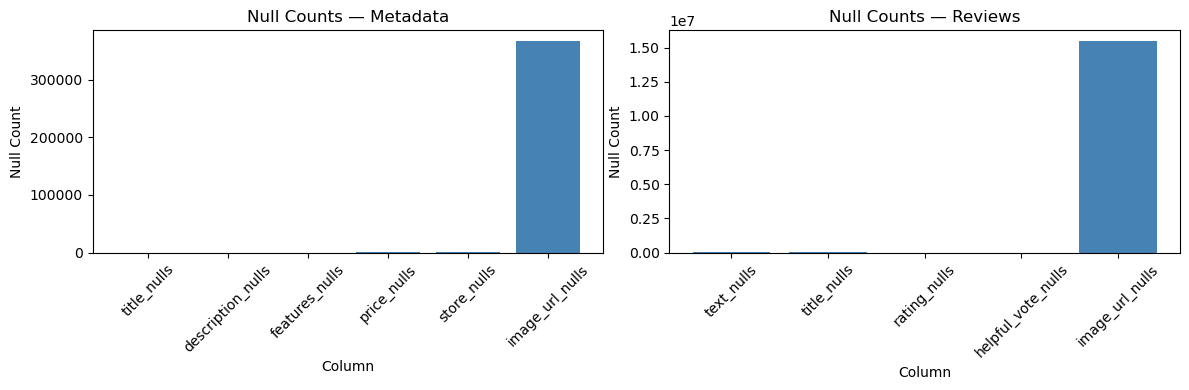

In [28]:
null_counts_meta = con.execute("""
    SELECT 
        COUNT(*) - COUNT(title)          AS title_nulls,
        COUNT(*) - COUNT(description)    AS description_nulls,
        COUNT(*) - COUNT(features)       AS features_nulls,
        COUNT(*) - COUNT(price)          AS price_nulls,
        COUNT(*) - COUNT(store)          AS store_nulls,
        COUNT(*) - COUNT(image_url)      AS image_url_nulls
    FROM meta
""").fetchdf()

null_counts_reviews = con.execute("""
    SELECT
        COUNT(*) - COUNT(text)           AS text_nulls,
        COUNT(*) - COUNT(title)          AS title_nulls,
        COUNT(*) - COUNT(rating)         AS rating_nulls,
        COUNT(*) - COUNT(helpful_vote)   AS helpful_vote_nulls,
        COUNT(*) - COUNT(image_url)      AS image_url_nulls
    FROM reviews
""").fetchdf()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(null_counts_meta.columns, null_counts_meta.iloc[0], color='steelblue')
axes[0].set_title('Null Counts — Metadata')
axes[0].set_xlabel('Column')
axes[0].set_ylabel('Null Count')
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(null_counts_reviews.columns, null_counts_reviews.iloc[0], color='steelblue')
axes[1].set_title('Null Counts — Reviews')
axes[1].set_xlabel('Column')
axes[1].set_ylabel('Null Count')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../results/plots/table_column_missingness_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

<b> Metadata: </b> <br>
price: ~500k nulls <br>
image_url: ~850k nulls <br>
These columns have significant missingness which would be expected for Amazon products. <br>
<b> Reviews:</b> <br>
image_url: ~15M => almost entirely null, which makes sense as most reviewers don't attach photos. <br>
text, title, and rating columns are nearly complete which is what matters for sentiment retrieval.

In [29]:
con.close()